<a href="https://colab.research.google.com/github/HakumenWorld/data-science-2026/blob/main/Pertemuan4_Febi_Kristiana_240401010231.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **PERTEMUAN 4: STATISTIKA DASAR & ANALISIS DATA**

## **Aktivitas Hands-on: Eksplorasi Statistik Dataset Iris**

### NAMA  : Febi Kristiana
### NIM   : 240401010231
### KELAS : IF403

## Langkah 1: Load & Inspect Dataset
Muat dataset iris menggunakan seaborn.load_dataset(). Tampilkan shape, dtypes, head(),
dan .describe().

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


df = sns.load_dataset('iris')

print(' SHAPE DATASET ')
print('Shape:', df.shape)
print('\n TIPE DATA (DTYPES) ')
print(df.dtypes)
print('\n 5 DATA PERTAMA (HEAD) ')
print(df.head())
print('\n STATISTIK DESKRIPTIF RINGKAS ')
print(df.describe().round(3))

 SHAPE DATASET 
Shape: (150, 5)

 TIPE DATA (DTYPES) 
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object

 5 DATA PERTAMA (HEAD) 
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa

 STATISTIK DESKRIPTIF RINGKAS 
       sepal_length  sepal_width  petal_length  petal_width
count       150.000      150.000       150.000      150.000
mean          5.843        3.057         3.758        1.199
std           0.828        0.436         1.765        0.762
min           4.300        2.000         1.000        0.100
25%           5.100        2.800         1.600        0.300
50%        

## Langkah 2: Statistik Deskriptif Lengkap
Hitung mean, median, std, varians, skewness, kurtosis untuk setiap kolom numerik.

In [4]:
for col_name in df.select_dtypes(include='number').columns:
    col = df[col_name]
    print(f'\n Statistik Deskriptif: {col_name} ')
    print(f' Mean      : {col.mean():.3f}')
    print(f' Median    : {col.median():.3f}')
    print(f' Std Dev   : {col.std():.3f}')
    print(f' Varians   : {col.var():.3f}')
    print(f' Skewness  : {col.skew():.3f}')
    print(f' Kurtosis  : {col.kurt():.3f}')


 Statistik Deskriptif: sepal_length 
 Mean      : 5.843
 Median    : 5.800
 Std Dev   : 0.828
 Varians   : 0.686
 Skewness  : 0.315
 Kurtosis  : -0.552

 Statistik Deskriptif: sepal_width 
 Mean      : 3.057
 Median    : 3.000
 Std Dev   : 0.436
 Varians   : 0.190
 Skewness  : 0.319
 Kurtosis  : 0.228

 Statistik Deskriptif: petal_length 
 Mean      : 3.758
 Median    : 4.350
 Std Dev   : 1.765
 Varians   : 3.116
 Skewness  : -0.275
 Kurtosis  : -1.402

 Statistik Deskriptif: petal_width 
 Mean      : 1.199
 Median    : 1.300
 Std Dev   : 0.762
 Varians   : 0.581
 Skewness  : -0.103
 Kurtosis  : -1.341


## Langkah 3: Analisis Distribusi (Histogram + KDE)
Buat histogram + KDE untuk sepal_length. Tambahkan garis mean dan median. Identifikasi
jenis distribusinya.

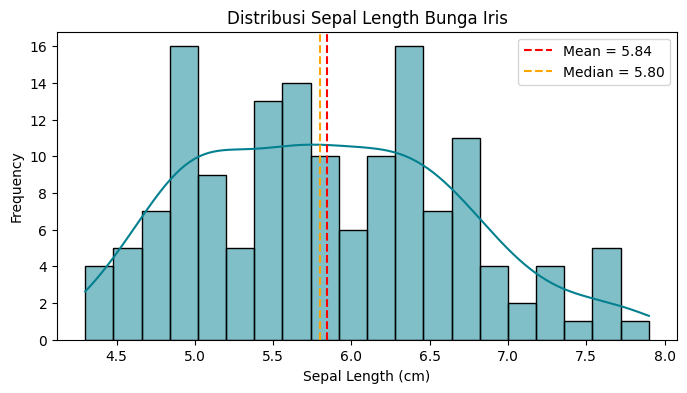

In [3]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(df['sepal_length'], kde=True, color='#028090', bins=20, ax=ax)

# Menambahkan garis Vertikal untuk Mean dan Median
mean_val = df['sepal_length'].mean()
median_val = df['sepal_length'].median()

ax.axvline(mean_val, color='red', linestyle='--', label=f"Mean = {mean_val:.2f}")
ax.axvline(median_val, color='orange', linestyle='--', label=f"Median = {median_val:.2f}")

ax.set_title('Distribusi Sepal Length Bunga Iris')
ax.set_xlabel('Sepal Length (cm)')
ax.set_ylabel('Frequency')
ax.legend()
plt.show()

### **Interpretasi Distribusi Sepal Length:**
* **Bentuk Distribusi:** Berdasarkan grafik Histogram dan kurva *Kernel Density Estimation* (KDE), data `sepal_length` cenderung berdistribusi **multimodal** atau mendekati **normal sedikit condong ke kanan** (*slightly right-skewed*).
* **Mean vs Median:** Nilai Mean ($5.84$ cm) sedikit lebih besar daripada nilai Median ($5.80$ cm). Jarak yang sangat tipis ini memperkuat bahwa distribusinya hampir simetris (mendekati normal), dengan sedikit ekor di sebelah kanan karena nilai *skewness* positif yang kecil.

## Langkah 4: Boxplot per Spesies
Buat boxplot petal_length per spesies. Identifikasi spesies dengan nilai terbesar, terkecil,
dan paling tersebar.



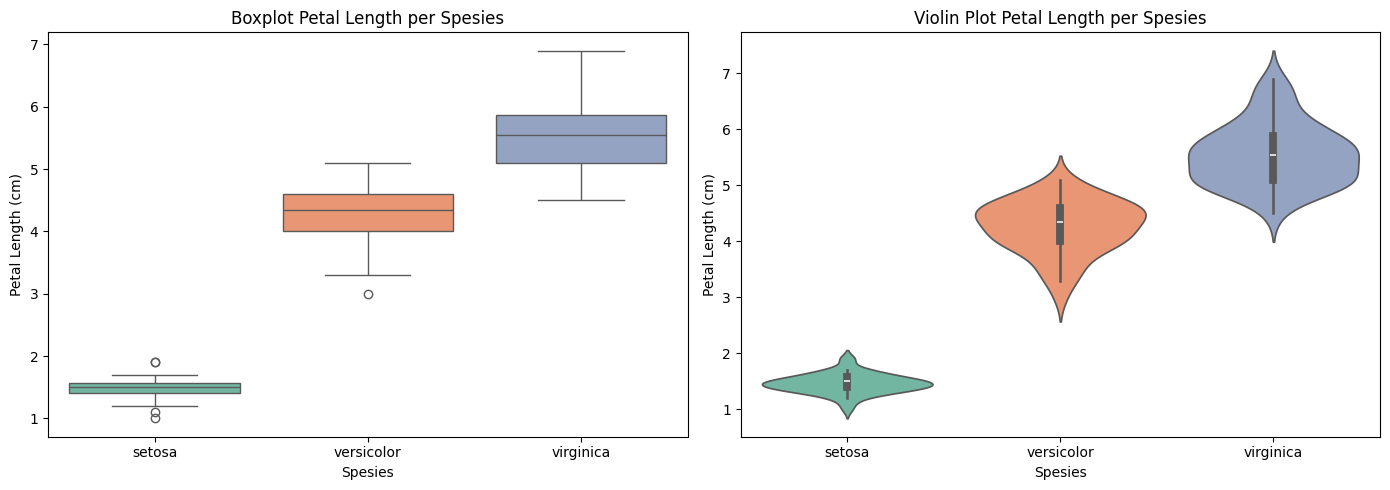

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot (Mnambahkan hue dan legend=False)
sns.boxplot(data=df, x='species', y='petal_length', hue='species', palette='Set2', legend=False, ax=axes[0])
axes[0].set_title('Boxplot Petal Length per Spesies')
axes[0].set_xlabel('Spesies')
axes[0].set_ylabel('Petal Length (cm)')

# Violin Plot (Menambahkan hue dan legend=False)
sns.violinplot(data=df, x='species', y='petal_length', hue='species', palette='Set2', inner='box', legend=False, ax=axes[1])
axes[1].set_title('Violin Plot Petal Length per Spesies')
axes[1].set_xlabel('Spesies')
axes[1].set_ylabel('Petal Length (cm)')

plt.tight_layout()
plt.show()

### **Interpretasi Boxplot & Violin Plot (`petal_length`):**
* **Spesies dengan Nilai Terbesar:** Spesies **Iris virginica** memiliki rata-rata dan nilai maksimum `petal_length` terbesar dibandingkan spesies lainnya.
* **Spesies dengan Nilai Terkecil:** Spesies **Iris setosa** memiliki nilai `petal_length` terkecil, dengan rentang data yang sangat pendek dan terpisah jauh dari dua spesies lainnya.
* **Spesies Paling Tersebar:** Spesies **Iris versicolor** dan **Iris virginica** memiliki sebaran data (*variance/rentang interkuartil*) yang jauh lebih lebar dan tersebar dibandingkan Iris setosa yang sangat mengelompok (konsisten).

## Langkah 5: Matriks Korelasi Pearson
Hitung matriks korelasi. Identifikasi pasangan kolom dengan korelasi tertinggi dan terendah.

In [7]:
# Menghitung matriks korelasi pearson (drop kolom non-numerik 'species')
corr = df.drop('species', axis=1).corr(method='pearson')
print(" MATRIKS KORELASI PEARSON ")
print(corr.round(3))
print("\n" + "-"*32)

# Menggunakan mask untuk mencari pasangan korelasi tertinggi dan terendah
mask = np.triu(np.ones(corr.shape, dtype=bool))
corr_masked = corr.where(~mask)

# Cari korelasi tertinggi
max_pair = corr_masked.stack().idxmax()
max_val = corr_masked.stack().max()

# Cari korelasi terendah (paling mendekati 0 atau negatif terkuat)
min_pair = corr_masked.stack().idxmin()
min_val = corr_masked.stack().min()

print(f'Korelasi Tertinggi : {max_pair} = {max_val:.3f}')
print(f'Korelasi Terendah  : {min_pair} = {min_val:.3f}')

 MATRIKS KORELASI PEARSON 
              sepal_length  sepal_width  petal_length  petal_width
sepal_length         1.000       -0.118         0.872        0.818
sepal_width         -0.118        1.000        -0.428       -0.366
petal_length         0.872       -0.428         1.000        0.963
petal_width          0.818       -0.366         0.963        1.000

--------------------------------
Korelasi Tertinggi : ('petal_width', 'petal_length') = 0.963
Korelasi Terendah  : ('petal_length', 'sepal_width') = -0.428


## Langkah 6: Scatter Plot & Heatmap
Buat scatter plot pasangan paling berkorelasi + heatmap lengkap. Sertakan narasi
interpretasi dalam Markdown.

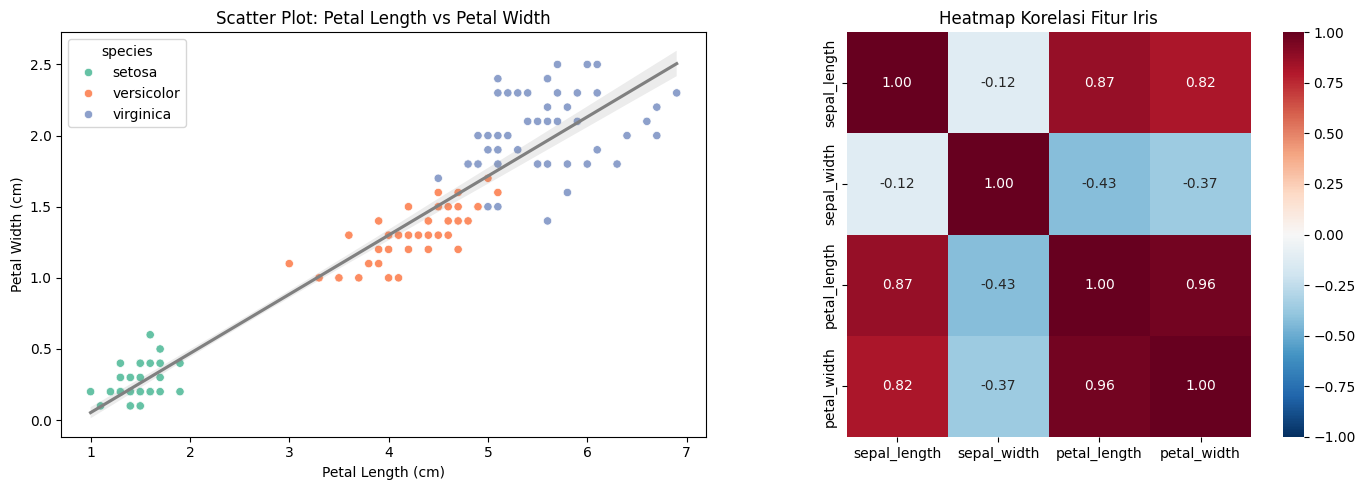

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter Plot pasangan paling berkorelasi (petal_length vs petal_width)
sns.scatterplot(data=df, x='petal_length', y='petal_width', hue='species', palette='Set2', ax=axes[0])
sns.regplot(data=df, x='petal_length', y='petal_width', scatter=False, color='gray', ax=axes[0])
axes[0].set_title('Scatter Plot: Petal Length vs Petal Width')
axes[0].set_xlabel('Petal Length (cm)')
axes[0].set_ylabel('Petal Width (cm)')

# Heatmap Korelasi
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', vmin=-1, vmax=1, square=True, ax=axes[1])
axes[1].set_title('Heatmap Korelasi Fitur Iris')

plt.tight_layout()
plt.show()

### **Interpretasi Analisis Korelasi dan Visualisasi:**
1. **Analisis Heatmap:** Fitur `petal_length` dan `petal_width` memiliki korelasi linear positif yang sangat kuat sebesar **0.96**. Hal ini menunjukkan bahwa seiring bertambah panjangnya mahkota bunga (petal), lebarnya pun pasti bertambah secara proporsional.
2. **Analisis Scatter Plot:** Terlihat jelas adanya pemisahan *cluster* antar spesies. **Iris setosa** berada di pojok kiri bawah (ukuran petal kecil dan konsisten), sedangkan **Iris versicolor** berada di area menengah, dan **Iris virginica** menduduki posisi kanan atas (ukuran petal paling besar). Garis regresi abu-abu mempertegas tren linear positif tersebut.

## KESIMPULAN

### Apa yang Dipelajari
Pada Pertemuan 4, saya mempelajari **statistika deskriptif** dan cara menganalisis hubungan antar fitur menggunakan **korelasi Pearson**.

### Temuan Utama
1. Distribusi dan perbedaan antar spesies terlihat dari histogram/boxplot/violin.
2. Hubungan korelasi antar fitur numerik terlihat jelas pada heatmap.

### Keterbatasan (Singkat)
Korelasi Pearson hanya menggambarkan hubungan **linear** antar variabel numerik.
